In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

In [11]:
# Load the dataset
df = pd.read_csv('imdb_top_250.csv')

In [18]:
#  Create a binary classification target: High (1) if Rating >= 8.5, else Low (0)
df['Target'] = (df['Rating'] >= 8.5).astype(int)

# Prepare features and target
X = df[['Rank', 'Year', 'Runtime']]
y = df['Target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


=== 1. Decision Tree Classifier ===


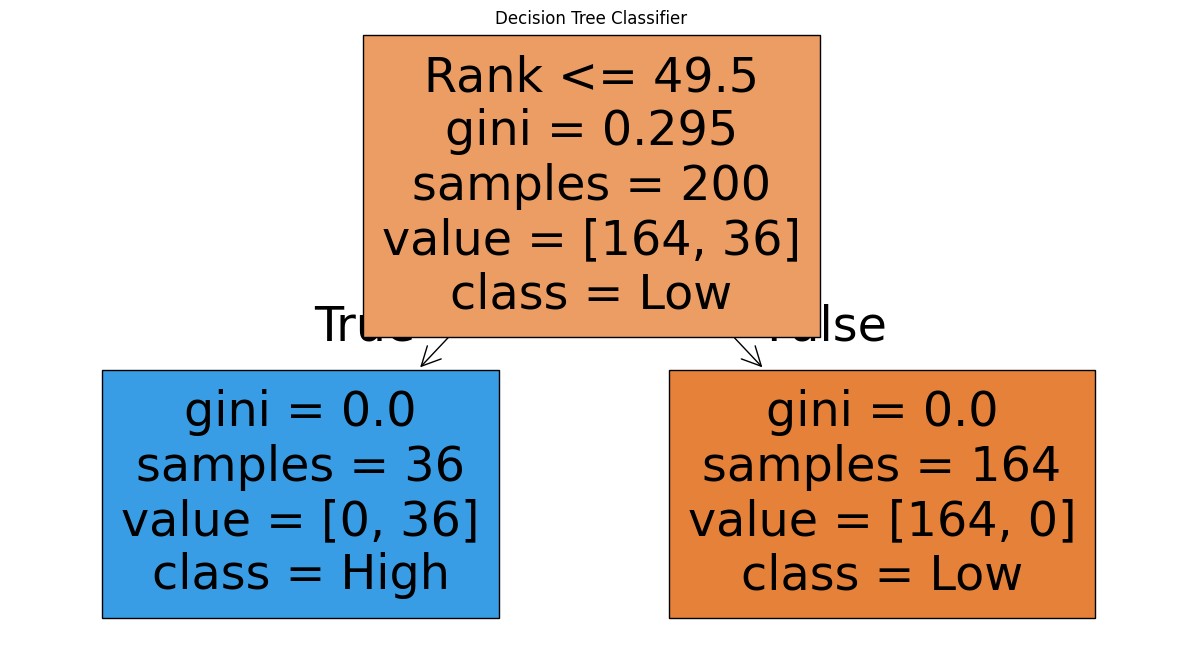

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        37
        High       1.00      1.00      1.00        13

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [19]:
# Train a Decision Tree Classifier and visualize the tree
print("\n=== 1. Decision Tree Classifier ===")
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(15, 8))
plot_tree(dt, feature_names=X.columns, class_names=['Low', 'High'], filled=True)
plt.title("Decision Tree Classifier")
plt.show()

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, target_names=['Low', 'High']))


=== 2. Overfitting Analysis ===


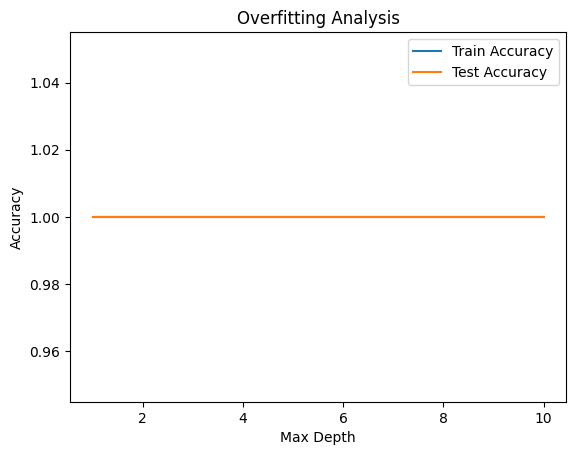

In [14]:
# 2. Analyze overfitting and control tree depth
print("\n=== 2. Overfitting Analysis ===")
depths = range(1, 11)
train_scores = []
test_scores = []

for depth in depths:
    temp_dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    temp_dt.fit(X_train, y_train)
    train_scores.append(temp_dt.score(X_train, y_train))
    test_scores.append(temp_dt.score(X_test, y_test))

plt.plot(depths, train_scores, label="Train Accuracy")
plt.plot(depths, test_scores, label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis")
plt.legend()
plt.show()

In [15]:
# 3. Train a Random Forest Classifier and compare accuracy
print("\n=== 3. Random Forest Classifier ===")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=['Low', 'High']))



=== 3. Random Forest Classifier ===
Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        37
        High       1.00      1.00      1.00        13

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50




=== 4. Feature Importances ===


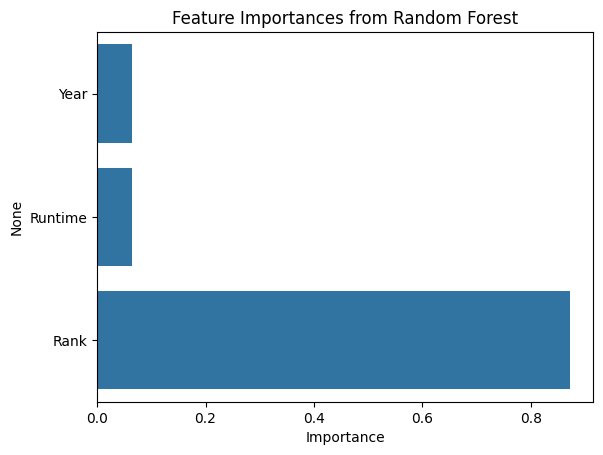

In [16]:
# 4. Interpret feature importances
print("\n=== 4. Feature Importances ===")
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance")
plt.show()

In [17]:
# 5. Evaluate using cross-validation
print("\n=== 5. Cross-Validation ===")
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())



=== 5. Cross-Validation ===
Cross-Validation Accuracy Scores: [0.6  1.   1.   1.   0.92]
Mean CV Accuracy: 0.9040000000000001
